# Part 1: simulating an altitude controller

Before implementing any controller on the real robot, it is a good practice to simulate its effects first. This allows to, e.g., (a) rapidly iterate between different instantiations, (b) mitigate the probability of implementing potentially dangerous mistakes, and (c) start distinguishing between theory and practice. 

In this first extremely simplified simulation, we immagine a drone that can only move in one dimension: the vertical one. 

The task is to design a control law that modulates the thrust generated by the motors, so to drive the Duckiedrone's altitude to a desired setpoint. The **process variable** is therefore drone's altitude, the **setpoint** is the desired altitude, and the **tracking error** is the difference, expressed in meters, between the setpoint and the drone's altitude.

The **DD24-B** outputs a **normalized thrust**, i.e., a value always between **[0.0, 1.0]** sent to PX4 via MAVROS2.

You should implement the discretized version of the PID control function in `pid_class.py`, inside the folder `packages/solution/solution/`:

$$u(t_k) = K_p e(t_k) + K_i \sum_{i=0}^{k} e(t_i)\,\Delta t + K_d \frac{e(t_k)-e(t_{k-1})}{\Delta t} + K$$

$$K_p, K_i, K_d = \text{PID gains} \qquad K = \text{hover thrust offset} \approx 0.44$$
$$e(t_k) = \text{error at time } t_k \qquad \Delta t = \text{time elapsed from previous iteration}$$

The extra offset term $K$ is the normalized thrust required to keep the drone hovering (counteracts gravity).

The output $u$ is **clipped to [0.0, 1.0]** — physically, you cannot have negative thrust or more than full throttle.

Write brief answers to all exercises in `answers_pid.md` inside `packages/solution/solution/`.

## Problem 1: Implement an Idealized PID

**Exercises**

1. Implement the `step` method to return only the constant $K$ (all other terms zero). At what value of $K$ does the drone take off? Set $K$ to **0.44** for the remainder of the questions.
2. Implement the P term. What happens when $K_p$ is 0.5? 2.0? 5.0?
3. Implement the D term. Set $K_p$ to zero. What happens when $K_d$ is 0.5? 2.0? 5.0?
4. Now tune $K_p$ and $K_d$ so that the drone comes to a steady hover. Describe the trade-off as you change the ratio of $K_p$ to $K_d$.
5. Implement the I term and observe the difference between PD and PID control. What role does the I term play in this system? What happens when $K_p$ and $K_d$ are set to zero?
6. Implement the `reset` method and test its behaviour. If implemented incorrectly, what problems can you anticipate reset causing?
7. Finally, tune the constants in your PID controller to the best of your abilities. When the setpoint is moving, the drone should chase the setpoint very closely. When the setpoint is still, the drone should converge exactly at the setpoint and not oscillate. Report your tuning values.

### Tuning the gains of your PID

To tune your PID, set the parameters ($K_p, K_i, K_d, K$) with the sliders below (you can also edit them directly in `z_pid.yaml` inside `packages/solution/solution/`).

The simulated drone should converge exactly at the setpoint and not oscillate!

The `PID` class in `pid_class.py` will automatically be used to control the simulated drone.

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys

EXERCISE_DIRECTORY = "/code/src/lx-dd-altitude-pid-control/packages/solution/solution"
GAINS_PATH = EXERCISE_DIRECTORY + "/z_pid.yaml"

sys.path.insert(0, EXERCISE_DIRECTORY)

from utils.writer import load_gains, update_gains
from drone_sim import VerticalDrone


def update(height_setpoint, kp, kd, ki, k, drag_coeff=0, latency=0, noise=0):
    from pid_class import PID

    update_gains(kp=kp, kd=kd, ki=ki, k=k, filepath=GAINS_PATH)

    pid_gains = load_gains(GAINS_PATH)

    my_pid_instance = PID(
        kp=pid_gains['Kp'],
        kd=pid_gains['Kd'],
        ki=pid_gains['Ki'],
        k=pid_gains['K'],
    )

    sim = VerticalDrone(
        pid=my_pid_instance,
        step_size=10,
        drag_coeff=drag_coeff,
        latency=latency,
        sensor_noise=noise,
        mass=0.7,  # mass in kg
    )

    sim.update_setpoint(height=height_setpoint)
    sim.simulate(end_time=15.0)
    sim.plot_step_response()

In [3]:
%matplotlib widget

import ipywidgets as widgets

kp_widget = widgets.FloatSlider(value=1.0, description='Kp', max=5.0, min=0.0)
kd_widget = widgets.FloatSlider(value=1.0, description='Kd', max=2.0, min=0.0)
ki_widget = widgets.FloatSlider(value=0.3, description='Ki', max=1.0, min=0.0)

k_widget = widgets.BoundedFloatText(value=0.44, max=1.0, min=0.0, description='K',
                                     step=0.01)
height_setpoint = widgets.FloatSlider(value=0.5, min=0.0, max=1.5, description='Setpoint')

ui = widgets.HBox(
    [
        widgets.VBox([kp_widget, kd_widget, ki_widget, k_widget]),
        widgets.VBox([height_setpoint]),
    ]
)

out = widgets.interactive_output(
    update,
    {
        'height_setpoint': height_setpoint,
        'kp': kp_widget,
        'kd': kd_widget,
        'ki': ki_widget,
        'k': k_widget,
    }
)

In [4]:
# Execute this cell to show the tuner
display(ui, out)

Output(outputs=({'output_type': 'display_data', 'data': {'text/plain': "Canvas(toolbar=Toolbar(toolitems=[('Ho…

## Problem 2: Tuning a PID with Latency

Now we introduce latency. Add a latency of **6 steps** in the widget below, which introduces 300 ms of latency (six steps at 20 Hz).

**Exercises**

1. Tune the constants in your PID controller to the best of your abilities. The drone should chase the setpoint very closely, but will converge more slowly when the setpoint is still. Report your tuning values.
2. Compare your tuning values to the values you obtained in Problem 1.
3. Explain the effect of latency on each control term.

In [5]:
# Execute this cell to show the tuner with latency
latency = widgets.BoundedIntText(value=6, description='Latency')
ui.children[1].children += (latency,)

out = widgets.interactive_output(
    update,
    {
        'height_setpoint': height_setpoint,
        'latency': latency,
        'kp': kp_widget,
        'kd': kd_widget,
        'ki': ki_widget,
        'k': k_widget,
    }
)

display(ui, out)

Output()

## Problem 3: Tuning a PID with Latency, Noise, and Drag

In the most realistic mode, you will tune a controller with latency, noise, and a drag coefficient.

The controller should be able to reach the setpoint with latency `3`, noise `0.005` (metres), and drag `0.05`.

**Exercises**

1. Tune with these arguments to be as good as possible. Report your tuning values.
2. Compare your tuning values to the values from Problems 1 and 2.

**After you finish this part of the project, make sure that you push the final versions of the files that you modified to your GitHub repo.**

In [6]:
# Execute this cell to show the tuner with latency, drag, and noise
drag_coeff = widgets.BoundedFloatText(value=0.05, description='Drag')
noise = widgets.BoundedFloatText(value=0.005, description='Noise (m)')

ui.children[1].children += (drag_coeff, noise,)

out = widgets.interactive_output(
    update,
    {
        'height_setpoint': height_setpoint,
        'drag_coeff': drag_coeff,
        'noise': noise,
        'kp': kp_widget,
        'kd': kd_widget,
        'ki': ki_widget,
        'k': k_widget,
    }
)

display(ui, out)

Output()

# Unit Test

The thrust output of the `step()` function in `pid_class.py` sent to PX4 via MAVROS2 must always be in **[0.0, 1.0]**. Values outside this range are physically meaningless (you cannot have negative thrust or more than full throttle) and MAVROS2 will reject them.

The test below checks this constraint by simulating the PID from the gains saved in `z_pid.yaml`. This approach to testing is called *unit testing*.

In [7]:
sys.path.insert(0, "/code/src/lx-dd-altitude-pid-control/tests")
from test_pid_output import TestPIDOutput

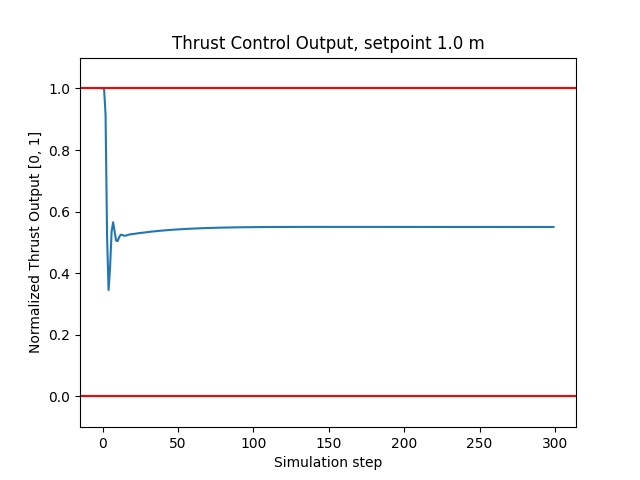

PASS: all 300 thrust values are within [0.0, 1.0]


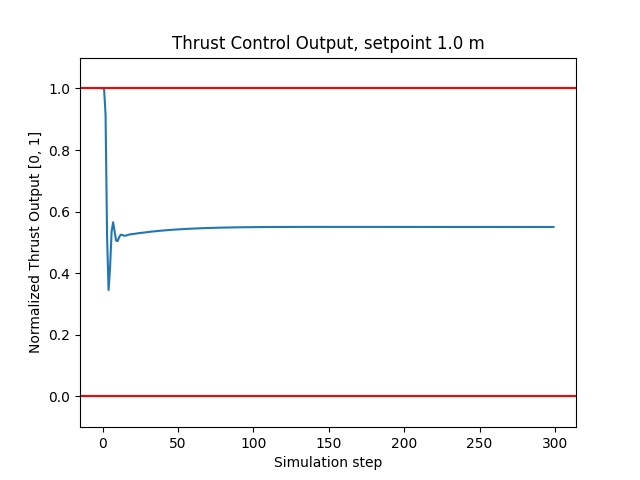

In [8]:
import sys
if EXERCISE_DIRECTORY not in sys.path:
    sys.path.insert(0, EXERCISE_DIRECTORY)

from pid_class import PID

Z_SETPOINT = 1.0  # Setpoint height [m]

test = TestPIDOutput(gains_path=GAINS_PATH, PID=PID, setpoint=Z_SETPOINT)
test.simulate_with_limits()